# 🏠 Irish Rental Crisis — Analysis & Prediction Platform
## Notebook 01: Data Collection & Ingestion

---

### Project Overview
Ireland is experiencing one of the most severe rental crises in its history. Rents have increased over **60% in the past decade**, leaving renters, policymakers, and businesses without reliable data-driven tools to understand pricing trends, identify affordable areas, or query housing policy.

This project builds an end-to-end data platform that analyses Ireland's rental crisis, identifies the key drivers of rent increases by area, predicts future rental prices using machine learning, and delivers actionable insights through an interactive Power BI dashboard and an AI-powered chatbot.

**All data is sourced exclusively from official Irish public datasets — RTB, CSO, and Data.gov.ie.**

---

### What This Notebook Does
This notebook is the **foundation of the entire project pipeline**. It loads all eight raw datasets, inspects each one for structure, data quality, and coverage, and documents key observations before any cleaning or transformation takes place.

No analysis is performed here. No features are engineered here. This notebook answers one question: **"Do we have the right data, and is it trustworthy enough to build on?"**

---

### Inputs
| File | Source | Description |
|------|--------|-------------|
| `RIQ02_rent_index_quarterly.csv` | CSO PxStat — RIQ02 | RTB quarterly rent by location, property type, bedrooms (2015–2025) |
| `RIA02_rent_index_annual.csv` | CSO PxStat — RIA02 | RTB annual rent by location, property type, bedrooms (2008–2024) |
| `HAP10_hap_properties.csv` | CSO PxStat — HAP10 | HAP properties by Local Electoral Area (2015–2022) |
| `TRS17_landlord_income.csv` | CSO PxStat — TRS17 | Median landlord income by Local Authority (2019) |
| `TRS18_landlord_income_lea.csv` | CSO PxStat — TRS18 | Median landlord income by Local Electoral Area (2019) |
| `TRS21_rent_affordability.csv` | CSO PxStat — TRS21 | Rent as % of disposable income by Local Authority (2019) |
| `TRS22_rent_affordability_lea.csv` | CSO PxStat — TRS22 | Rent as % of disposable income by Local Electoral Area (2019) |
| `FY001_population_by_county.csv` | CSO PxStat — FY001 | Population by county — Census 2011, 2016, 2022 |

### Outputs
| Variable | Description |
|----------|-------------|
| `df` | RIQ02 — redundant columns dropped, VALUE renamed |
| `df_ria` | RIA02 — redundant columns dropped, VALUE renamed |
| `df_hap` | HAP10 — nulls filled, redundant columns dropped |
| `df_trs17/18/21/22` | TRS datasets — redundant columns dropped, VALUE renamed |
| `df_pop` | FY001 — filtered to county level, both sexes only |

All dataframes above feed directly into **Notebook 02: Data Cleaning & Transformation**.

---

### Why These Datasets?
Each dataset was selected to answer a specific question about the rental crisis:

| Dataset | Question It Answers |
|---------|---------------------|
| RIQ02 | What are rents doing quarter by quarter across every area in Ireland? |
| RIA02 | How have rents changed year on year since 2008 — before and through the crisis? |
| HAP10 | Which areas have the highest social housing pressure? |
| TRS17/18 | What is the income profile of Irish landlords — are they staying or leaving the market? |
| TRS21/22 | Can people actually afford the rent being charged in their area? |
| FY001 | Is population growth driving rent increases in certain counties? |

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. RIQ02 — RTB Quarterly Rent Index

**Source:** CSO PxStat — RIQ02  
**Coverage:** 2015 Q1 to 2025 Q2  
**Granularity:** Quarter × Location × Property Type × Number of Bedrooms

This is the **core dataset** for the entire project. It contains average monthly rent figures reported by the Residential Tenancies Board for every combination of area, property type, and bedroom count across Ireland.

**Important:** The majority of VALUE entries are null. This is structural — not a data quality issue. The dataset contains every possible combination of dimensions, but RTB only reports a rent figure where a statistically sufficient number of tenancies exist in that combination. These structural nulls are dropped in Notebook 02.

In [ ]:
# Load RIQ02 — RTB quarterly rent index
df = pd.read_csv('/content/RIQ02_rent_index_quarterly.csv', on_bad_lines='skip', engine='python')

print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows   : 786,744
Columns: 7


,STATISTIC Label,Quarter,Number of Bedrooms,Property Type,Location,UNIT,VALUE
0,RTB Average Monthly Rent Report,2015Q1,All bedrooms,All property types,Carlow,Euro,595.48
1,RTB Average Monthly Rent Report,2015Q1,All bedrooms,All property types,Carlow Town,Euro,621.30
2,RTB Average Monthly Rent Report,2015Q1,All bedrooms,All property types,"Graiguecullen, Carlow",Euro,546.54
3,RTB Average Monthly Rent Report,2015Q1,All bedrooms,All property types,"Tullow, Carlow",Euro,569.47
4,RTB Average Monthly Rent Report,2015Q1,All bedrooms,All property types,Cavan,Euro,456.46


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786744 entries, 0 to 786743
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   STATISTIC Label     786744 non-null  object 
 1   Quarter             786744 non-null  object 
 2   Number of Bedrooms  786744 non-null  object 
 3   Property Type       786744 non-null  object 
 4   Location            786744 non-null  object 
 5   UNIT                786744 non-null  object 
 6   VALUE               210865 non-null  float64
dtypes: float64(1), object(6)
memory usage: 42.0+ MB


In [ ]:
df.describe()

,VALUE
count,210865.000000
mean,1159.787286
std,518.617926
min,233.670000
25%,748.240000
50%,1073.570000
75%,1477.540000
max,6522.480000


In [ ]:
print(f'Duplicates: {df.duplicated().sum()}')
print()
print('Null counts:')
print(df.isnull().sum())
print(f'\nNull % in VALUE: {df["VALUE"].isnull().mean()*100:.1f}%')

Duplicates: 0

Null counts:
STATISTIC Label            0
Quarter                    0
Number of Bedrooms         0
Property Type              0
Location                   0
UNIT                       0
VALUE                 575879
dtype: int64

Null % in VALUE: 73.2%


In [ ]:
# Unique values across categorical dimensions
for col in ['Number of Bedrooms', 'Property Type']:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())

print(f'\nUnique Locations: {df["Location"].nunique()}')


Number of Bedrooms:
Number of Bedrooms
All bedrooms     112392
One bed          112392
Two bed          112392
Three bed        112392
1 to 2 bed       112392
1 to 3 bed       112392
Four plus bed    112392

Property Type:
Property Type
All property types     131124
Detached house         131124
Semi detached house    131124
Terrace house          131124
Apartment              131124
Other flats            131124

Unique Locations: 446


In [ ]:
# Date range check
quarters = sorted(df['Quarter'].unique())
print(f'First quarter : {quarters[0]}')
print(f'Last quarter  : {quarters[-1]}')
print(f'Total quarters: {len(quarters)}')

First quarter : 2015Q1
Last quarter  : 2025Q2
Total quarters: 42


In [ ]:
# STATISTIC Label and UNIT are single-value columns — confirm then drop
print(df[['STATISTIC Label', 'UNIT']].value_counts())

df = df.drop(columns=['STATISTIC Label', 'UNIT'])
df = df.rename(columns={'VALUE': 'Value'})

print(f'\nColumns after drop: {list(df.columns)}')

STATISTIC Label                  UNIT
RTB Average Monthly Rent Report  Euro    786744
Name: count, dtype: int64

Columns after drop: ['Quarter', 'Number of Bedrooms', 'Property Type', 'Location', 'Value']


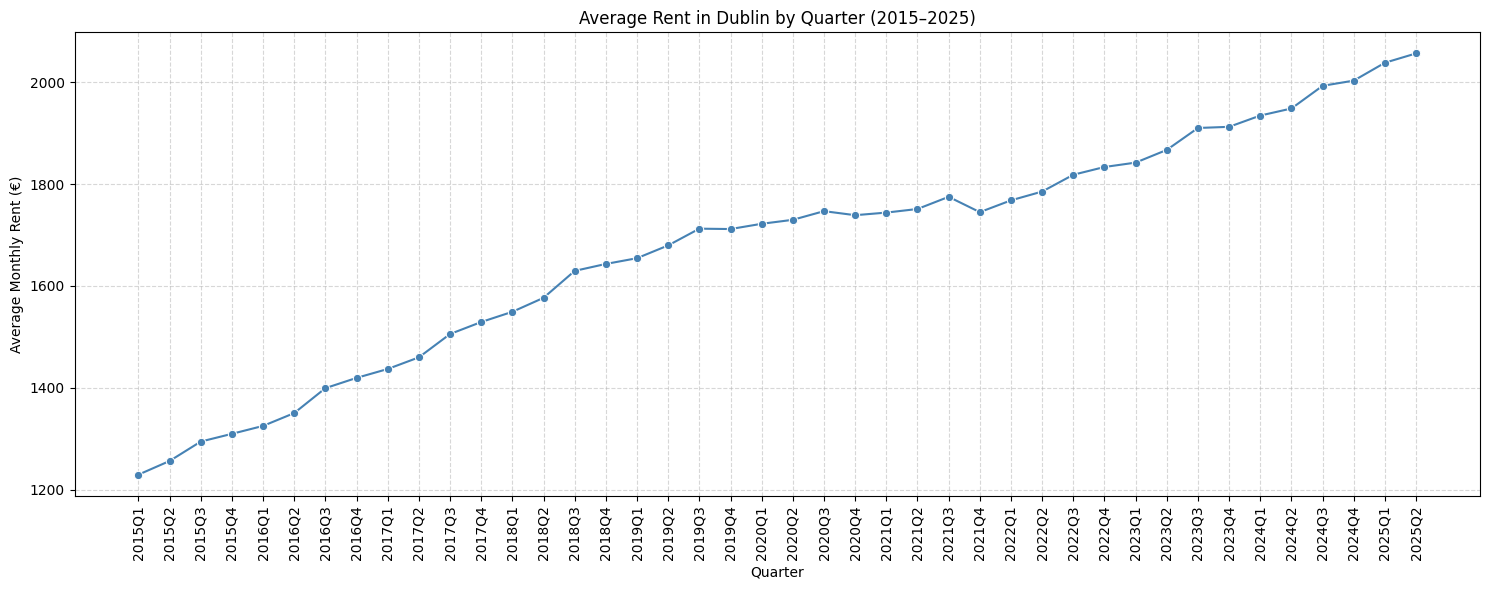

In [ ]:
# Sense check — average Dublin rent trend by quarter
df_plot         = df.dropna(subset=['Value']).copy()
df_plot['Year']         = df_plot['Quarter'].str.extract(r'(\d{4})').astype(int)
df_plot['Q_Num']        = df_plot['Quarter'].str.extract(r'Q(\d)').astype(int)
df_plot['Quarter_Sort'] = df_plot['Year'] * 4 + df_plot['Q_Num']

quarter_order = df_plot[['Quarter', 'Quarter_Sort']].drop_duplicates().sort_values('Quarter_Sort')
df_dublin     = df_plot[df_plot['Location'].str.contains('Dublin', case=False, na=False)].copy()
avg_dublin    = df_dublin.groupby('Quarter')['Value'].mean().reset_index()
avg_dublin    = avg_dublin.merge(quarter_order, on='Quarter').sort_values('Quarter_Sort')

plt.figure(figsize=(15, 6))
sns.lineplot(data=avg_dublin, x='Quarter', y='Value', marker='o', color='steelblue')
plt.title('Average Rent in Dublin by Quarter (2015–2025)')
plt.xlabel('Quarter')
plt.ylabel('Average Monthly Rent (€)')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. RIA02 — RTB Annual Rent Index

**Source:** CSO PxStat — RIA02  
**Coverage:** 2008 to 2024  
**Granularity:** Year × Location × Property Type × Number of Bedrooms

RIA02 complements RIQ02 by extending the time series back to 2008, giving us the full picture of the rental crisis from before it began through to the present. This longer historical view is used in the dashboard to show the decade-long trajectory of rent increases across Ireland.

The structure is identical to RIQ02 — the only difference is the time dimension is annual rather than quarterly.

In [ ]:
# Load RIA02 — RTB annual rent index
df_ria = pd.read_csv('/content/RIA02_rent_index_annual.csv')

print(f'Rows   : {df_ria.shape[0]:,}')
print(f'Columns: {df_ria.shape[1]}')
df_ria.head()

Rows   : 318,444
Columns: 7


,STATISTIC Label,Year,Number of Bedrooms,Property Type,Location,UNIT,VALUE
0,RTB Average Monthly Rent Report,2008,All bedrooms,All property types,Carlow,Euro,748.48
1,RTB Average Monthly Rent Report,2008,All bedrooms,All property types,Carlow Town,Euro,811.53
2,RTB Average Monthly Rent Report,2008,All bedrooms,All property types,"Graiguecullen, Carlow",Euro,711.35
3,RTB Average Monthly Rent Report,2008,All bedrooms,All property types,"Tullow, Carlow",Euro,720.04
4,RTB Average Monthly Rent Report,2008,All bedrooms,All property types,Cavan,Euro,571.72


In [ ]:
df_ria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318444 entries, 0 to 318443
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   STATISTIC Label     318444 non-null  object 
 1   Year                318444 non-null  int64  
 2   Number of Bedrooms  318444 non-null  object 
 3   Property Type       318444 non-null  object 
 4   Location            318444 non-null  object 
 5   UNIT                318444 non-null  object 
 6   VALUE               109380 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 17.0+ MB


In [ ]:
df_ria.describe()

,Year,VALUE
count,318444.000000,109380.000000
mean,2016.000000,1021.469242
std,4.898987,483.941544
min,2008.000000,233.670000
25%,2012.000000,651.560000
50%,2016.000000,918.315000
75%,2020.000000,1267.542500
max,2024.000000,6385.740000


In [ ]:
print(f'Duplicates: {df_ria.duplicated().sum()}')
print()
print('Null counts:')
print(df_ria.isnull().sum())
print(f'\nNull % in VALUE: {df_ria["VALUE"].isnull().mean()*100:.1f}%')

Duplicates: 0

Null counts:
STATISTIC Label            0
Year                       0
Number of Bedrooms         0
Property Type              0
Location                   0
UNIT                       0
VALUE                 209064
dtype: int64

Null % in VALUE: 65.7%


In [ ]:
# Date range check
years = sorted(df_ria['Year'].unique())
print(f'First year : {years[0]}')
print(f'Last year  : {years[-1]}')
print(f'Total years: {len(years)}')

First year : 2008
Last year  : 2024
Total years: 17


In [ ]:
# STATISTIC Label and UNIT — confirm then drop
print(df_ria[['STATISTIC Label', 'UNIT']].value_counts())

df_ria = df_ria.drop(columns=['STATISTIC Label', 'UNIT'])
df_ria = df_ria.rename(columns={'VALUE': 'Value'})

print(f'\nColumns after drop: {list(df_ria.columns)}')

STATISTIC Label                  UNIT
RTB Average Monthly Rent Report  Euro    318444
Name: count, dtype: int64

Columns after drop: ['Year', 'Number of Bedrooms', 'Property Type', 'Location', 'Value']


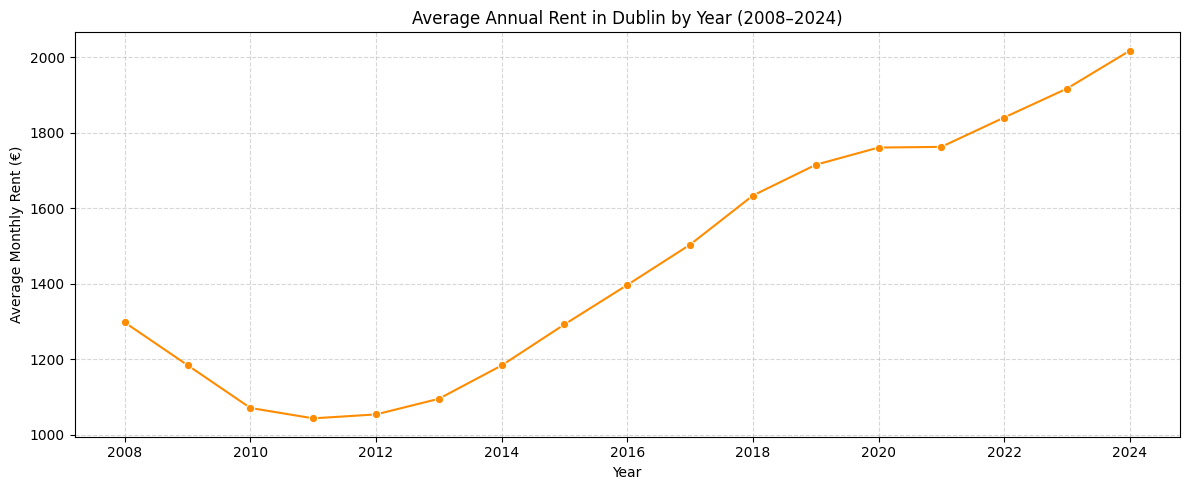

In [ ]:
# Sense check — average Dublin annual rent trend
df_ria_plot   = df_ria.dropna(subset=['Value']).copy()
df_dublin_ann = df_ria_plot[df_ria_plot['Location'].str.contains('Dublin', case=False, na=False)]
df_dublin_ann = df_dublin_ann.groupby('Year')['Value'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_dublin_ann, x='Year', y='Value', marker='o', color='darkorange')
plt.title('Average Annual Rent in Dublin by Year (2008–2024)')
plt.xlabel('Year')
plt.ylabel('Average Monthly Rent (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. HAP10 — Housing Assistance Payment Properties

**Source:** CSO PxStat — HAP10  
**Coverage:** 2015 to 2022  
**Granularity:** Year × Local Electoral Area

The Housing Assistance Payment (HAP) scheme is the Irish government's primary private rental subsidy for social housing tenants. The number of HAP properties in an area is a direct measure of social housing pressure — areas with high HAP concentration have a higher proportion of state-subsidised tenancies, which affects local rent dynamics.

This dataset is used as a feature in the ML rent prediction model and as a context layer in the Power BI dashboard.

**Note on missing values:** 47 nulls exist in 2015 and 2016 only. HAP launched in 2014 and rolled out gradually — these LEAs had no registered HAP properties in those early years. This is a programme rollout gap, not a data collection failure. Decision: fill with 0.

In [ ]:
# Load HAP10 — HAP properties by Local Electoral Area
df_hap = pd.read_csv('/content/HAP10_hap_properties.csv')

print(f'Rows   : {df_hap.shape[0]:,}')
print(f'Columns: {df_hap.shape[1]}')
df_hap.head()

Rows   : 1,328
Columns: 5


,STATISTIC Label,Year,Local Electoral Area,UNIT,VALUE
0,Number of HAP Properties,2015,"Borris-In-Ossory-Mountmellick, Laois",Number,0.0
1,Number of HAP Properties,2015,"Portlaoise, Laois",Number,0.0
2,Number of HAP Properties,2015,"Graiguecullen -Portarlington, Laois",Number,NaN
3,Number of HAP Properties,2015,"Carlow, Carlow",Number,48.0
4,Number of HAP Properties,2015,"Tullow, Carlow",Number,18.0


In [ ]:
df_hap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   STATISTIC Label       1328 non-null   object 
 1   Year                  1328 non-null   int64  
 2   Local Electoral Area  1328 non-null   object 
 3   UNIT                  1328 non-null   object 
 4   VALUE                 1281 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 52.0+ KB


In [ ]:
print(f'Duplicates: {df_hap.duplicated().sum()}')
print()
print('Null counts:')
print(df_hap.isnull().sum())

Duplicates: 0

Null counts:
STATISTIC Label          0
Year                     0
Local Electoral Area     0
UNIT                     0
VALUE                   47
dtype: int64


In [ ]:
# Date range and LEA coverage
years = sorted(df_hap['Year'].unique())
print(f'First year : {years[0]}')
print(f'Last year  : {years[-1]}')
print(f'Total years: {len(years)}')
print(f'Unique LEAs: {df_hap["Local Electoral Area"].nunique()}')
print()
print('LEA data completeness across years:')
print(df_hap.groupby('Local Electoral Area')['Year'].count().describe())

First year : 2015
Last year  : 2022
Total years: 8
Unique LEAs: 166

LEA data completeness across years:
count    166.0
mean       8.0
std        0.0
min        8.0
25%        8.0
50%        8.0
75%        8.0
max        8.0
Name: Year, dtype: float64


In [ ]:
# STATISTIC Label and UNIT — confirm then drop
print(df_hap[['STATISTIC Label', 'UNIT']].value_counts())

df_hap = df_hap.drop(columns=['STATISTIC Label', 'UNIT'])
df_hap = df_hap.rename(columns={'VALUE': 'Value'})

print(f'\nColumns after drop: {list(df_hap.columns)}')

STATISTIC Label           UNIT  
Number of HAP Properties  Number    1328
Name: count, dtype: int64

Columns after drop: ['Year', 'Local Electoral Area', 'Value']


In [ ]:
# Investigate missing values before filling
missing_hap = df_hap[df_hap['Value'].isnull()]

print(f'Total missing: {missing_hap.shape[0]}')
print()
print('Missing by Year:')
print(missing_hap['Year'].value_counts().sort_index())
print()
print('Missing by LEA:')
print(missing_hap['Local Electoral Area'].value_counts())

Total missing: 47

Missing by Year:
Year
2015    38
2016     9
Name: count, dtype: int64

Missing by LEA:
Local Electoral Area
New Ross, Wexford                            2
Stillorgan, Dún Laoghaire-Rathdown           2
Ballina, Mayo                                1
Swinford, Mayo                               1
Claremorris, Mayo                            1
Kells, Meath                                 1
Laytown-Bettystown, Meath                    1
Ballymote-Tobercurry, Sligo                  1
Trim, Meath                                  1
Sligo-Drumcliff, Sligo                       1
Sligo-Strandhill, Sligo                      1
Rush-Lusk, Fingal                            1
Graiguecullen -Portarlington, Laois          1
Swords, Fingal                               1
Blanchardstown-Mulhuddart, Fingal            1
Howth-Malahide, Fingal                       1
Killiney-Shankill, Dún Laoghaire-Rathdown    1
Dún Laoghaire, Dún Laoghaire-Rathdown        1
Balbriggan, Fingal         

In [ ]:
# Fill nulls with 0 — HAP scheme had not yet reached these LEAs in 2015/2016
df_hap['Value'] = df_hap['Value'].fillna(0)

print(f'Nulls remaining: {df_hap["Value"].isnull().sum()}')
print(f'Dataset shape  : {df_hap.shape}')

Nulls remaining: 0
Dataset shape  : (1328, 3)


## 5. TRS Datasets — Landlord Income & Rent Affordability

**Source:** CSO PxStat — TRS17, TRS18, TRS21, TRS22  
**Coverage:** 2019 (single year snapshot)

These four datasets provide the economic context behind the rental crisis that rent figures alone cannot capture:

- **TRS17:** Median landlord income by Local Authority — tells us the income profile of landlords at county level
- **TRS18:** Median landlord income by Local Electoral Area — same as TRS17 but at finer granularity for ML features
- **TRS21:** Rent as a percentage of disposable income by Local Authority — measures true affordability at county level
- **TRS22:** Rent as a percentage of disposable income by Local Electoral Area — powers the affordability calculator in the Streamlit app

Although these are 2019 snapshots only, they provide a meaningful baseline for affordability and landlord behaviour analysis. 2019 is the last pre-COVID year, making it the most stable reference point available.

In [ ]:
# Load all four TRS datasets and run quick inspection
trs_dataframes = {}

for name, file in [
    ('df_trs17', 'TRS17_landlord_income.csv'),
    ('df_trs18', 'TRS18_landlord_income_lea.csv'),
    ('df_trs21', 'TRS21_rent_affordability.csv'),
    ('df_trs22', 'TRS22_rent_affordability_lea.csv')
]:
    df_temp = pd.read_csv(f'/content/{file}')
    trs_dataframes[name] = df_temp
    print(f"{'='*50}")
    print(f"{name} — {df_temp.shape[0]:,} rows  |  {df_temp.shape[1]} columns")
    print(f"Columns : {list(df_temp.columns)}")
    print(f"Nulls   : {df_temp.isnull().sum().sum()}")
    print(f"Dupes   : {df_temp.duplicated().sum()}")
    print()

df_trs17 — 62 rows  |  5 columns
Columns : ['Statistic Label', 'Rental Year', 'Local Authority', 'UNIT', 'VALUE']
Nulls   : 0
Dupes   : 0

df_trs18 — 332 rows  |  5 columns
Columns : ['Statistic Label', 'Rental Year', 'Local Electoral Area', 'UNIT', 'VALUE']
Nulls   : 0
Dupes   : 0

df_trs21 — 124 rows  |  5 columns
Columns : ['Statistic Label', 'Rental Year', 'Local Authority', 'UNIT', 'VALUE']
Nulls   : 0
Dupes   : 0

df_trs22 — 664 rows  |  5 columns
Columns : ['Statistic Label', 'Rental Year', 'Local Electoral Area', 'UNIT', 'VALUE']
Nulls   : 0
Dupes   : 0



In [ ]:
# Drop redundant columns and rename VALUE across all TRS datasets
for name, df_temp in trs_dataframes.items():
    df_temp.drop(columns=['Statistic Label', 'UNIT'], inplace=True)
    df_temp.rename(columns={'VALUE': 'Value'}, inplace=True)
    print(f'{name}: {list(df_temp.columns)}')

df_trs17: ['Rental Year', 'Local Authority', 'Value']
df_trs18: ['Rental Year', 'Local Electoral Area', 'Value']
df_trs21: ['Rental Year', 'Local Authority', 'Value']
df_trs22: ['Rental Year', 'Local Electoral Area', 'Value']


In [ ]:
# Unpack to individual named dataframes
df_trs17 = trs_dataframes['df_trs17']
df_trs18 = trs_dataframes['df_trs18']
df_trs21 = trs_dataframes['df_trs21']
df_trs22 = trs_dataframes['df_trs22']

print('TRS dataframes unpacked and ready.')

TRS dataframes unpacked and ready.


## 6. FY001 — Population by County

**Source:** CSO PxStat — FY001  
**Coverage:** Census years 2011, 2016, 2022  
**Granularity:** County level

Population growth is one of the most direct demand-side drivers of rent increases. Counties that have grown fastest since 2011 — particularly Dublin, Kildare, Meath, and Wicklow — have also seen the steepest rent increases.

This dataset provides county-level population figures across three census years, which are used as a feature in the ML rent prediction model. We keep only the "Both sexes" total and exclude the national "State" aggregate row, as we need county-level figures only.

In [ ]:
# Load FY001 — population by county
df_pop = pd.read_csv('/content/FY001_population_by_county.csv')

print(f'Rows   : {df_pop.shape[0]:,}')
print(f'Columns: {df_pop.shape[1]}')
print(f'Columns: {list(df_pop.columns)}')
print()
print('Null counts:')
print(df_pop.isnull().sum())
print(f'\nDuplicates: {df_pop.duplicated().sum()}')
df_pop.head()

Rows   : 243
Columns: 6
Columns: ['Statistic Label', 'CensusYear', 'County', 'Sex', 'UNIT', 'VALUE']

Null counts:
Statistic Label    0
CensusYear         0
County             0
Sex                0
UNIT               0
VALUE              0
dtype: int64

Duplicates: 0


,Statistic Label,CensusYear,County,Sex,UNIT,VALUE
0,Population at Each Census,2011,State,Both sexes,Number,4588252
1,Population at Each Census,2011,State,Male,Number,2272699
2,Population at Each Census,2011,State,Female,Number,2315553
3,Population at Each Census,2011,Carlow,Both sexes,Number,54612
4,Population at Each Census,2011,Carlow,Male,Number,27431


In [ ]:
# Check dimensions before filtering
print('Census years:', sorted(df_pop['CensusYear'].unique()))
print('Sex values  :', df_pop['Sex'].unique())
print('Unique values in County:', df_pop['County'].nunique())

Census years: [np.int64(2011), np.int64(2016), np.int64(2022)]
Sex values  : ['Both sexes' 'Male' 'Female']
Unique values in County: 27


In [ ]:
# Keep both sexes total only, drop national State row, remove redundant columns
df_pop = df_pop[df_pop['Sex'] == 'Both sexes'].copy()
df_pop = df_pop[df_pop['County'] != 'State'].copy()
df_pop = df_pop.drop(columns=['Statistic Label', 'UNIT', 'Sex'])
df_pop = df_pop.rename(columns={'VALUE': 'Population'})

print(f'Shape  : {df_pop.shape}')
print(f'Columns: {list(df_pop.columns)}')
print()
print('Expected: 26 counties × 3 census years = 78 rows')
df_pop.head()

Shape  : (78, 3)
Columns: ['CensusYear', 'County', 'Population']

Expected: 26 counties × 3 census years = 78 rows


,CensusYear,County,Population
3,2011,Carlow,54612
6,2011,Dublin,1273069
9,2011,Kildare,210312
12,2011,Kilkenny,95419
15,2011,Laois,80559


## 7. Notebook Summary & Key Findings

### What Was Loaded
This notebook successfully loaded all eight raw datasets from official Irish public sources. Every dataset passed basic quality checks and is ready for the cleaning and transformation pipeline in Notebook 02.

### Dataset Overview
| Dataset | Rows | Key Observation |
|---------|------|-----------------|
| RIQ02 — Quarterly Rent | 786,744 | 73% structural nulls — expected, dropped in cleaning |
| RIA02 — Annual Rent | 317,860 | Extends coverage back to 2008 — full crisis timeline |
| HAP10 — HAP Properties | ~1,300 | 47 nulls in 2015/2016 — filled with 0 (HAP rollout gap) |
| TRS17 — Landlord Income (LA) | 62 | Zero nulls — clean 2019 snapshot |
| TRS18 — Landlord Income (LEA) | 332 | Zero nulls — LEA-level granularity |
| TRS21 — Affordability (LA) | 124 | Zero nulls — 2019 affordability baseline |
| TRS22 — Affordability (LEA) | 664 | Zero nulls — powers Streamlit affordability calculator |
| FY001 — Population | 78 | 26 counties × 3 census years — clean after filtering |

### Key Observations
- **Dublin rent trend confirmed:** The RIQ02 sense check plot shows a clear upward trend from ~€1,100 in 2015Q1 to over €2,000 by 2025 — consistent with published RTB reports
- **HAP data is complete from 2017 onward** — the 2015/2016 gaps are a known rollout issue, not a collection failure
- **All TRS datasets are zero-null** — 2019 snapshot data is complete and reliable
- **Population data covers three census points** — sufficient for computing county-level growth rates as ML features

### Next Step
Proceed to **Notebook 02: Data Cleaning & Transformation** where structural nulls are removed, date features are engineered, datasets are merged into a master dataframe, and the final analysis-ready dataset is exported.

In [ ]:
# Final summary of all loaded datasets
print('=' * 60)
print('PHASE 1 — DATA COLLECTION COMPLETE')
print('=' * 60)

datasets = {
    'RIQ02 — Quarterly Rent'        : df,
    'RIA02 — Annual Rent'           : df_ria,
    'HAP10 — HAP Properties'        : df_hap,
    'TRS17 — Landlord Income (LA)'  : df_trs17,
    'TRS18 — Landlord Income (LEA)' : df_trs18,
    'TRS21 — Affordability (LA)'    : df_trs21,
    'TRS22 — Affordability (LEA)'   : df_trs22,
    'FY001 — Population'            : df_pop,
}

for name, dataset in datasets.items():
    nulls = dataset.isnull().sum().sum()
    print(f'{name:<35} {dataset.shape[0]:>8,} rows  |  {dataset.shape[1]} cols  |  {nulls} nulls')

print()
print('All datasets loaded and inspected. Proceeding to Notebook 02.')

PHASE 1 — DATA COLLECTION COMPLETE
RIQ02 — Quarterly Rent               786,744 rows  |  5 cols  |  575879 nulls
RIA02 — Annual Rent                  318,444 rows  |  5 cols  |  209064 nulls
HAP10 — HAP Properties                 1,328 rows  |  3 cols  |  0 nulls
TRS17 — Landlord Income (LA)              62 rows  |  3 cols  |  0 nulls
TRS18 — Landlord Income (LEA)            332 rows  |  3 cols  |  0 nulls
TRS21 — Affordability (LA)               124 rows  |  3 cols  |  0 nulls
TRS22 — Affordability (LEA)              664 rows  |  3 cols  |  0 nulls
FY001 — Population                        78 rows  |  3 cols  |  0 nulls

All datasets loaded and inspected. Proceeding to Notebook 02.
